In [1]:
import pandas as pd
import numpy as np
import time
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               HistGradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

os.makedirs('../results/final', exist_ok=True)
os.makedirs('../results/final/figures', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)

LABEL_MAP   = {0: 'Benign', 1: 'DoS', 2: 'DDoS', 3: 'Mirai', 4: 'Spoofing'}
CLASS_NAMES = ['Benign', 'DoS', 'DDoS', 'Mirai', 'Spoofing']
MODELS      = ['DT', 'RF', 'XGB', 'LGBM', 'ET', 'HGB', 'CAT', 'BRF']

print("All imports successful.")

All imports successful.


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nClass distribution (train):\n{y_train.value_counts().sort_index().rename(LABEL_MAP)}")
print(f"\nClass distribution (test):\n{y_test.value_counts().sort_index().rename(LABEL_MAP)}")

X_train: (1062114, 30)
X_test:  (265529, 30)

Class distribution (train):
Label_encoded
Benign      318298
DoS         239759
DDoS        239095
Mirai       139403
Spoofing    125559
Name: count, dtype: int64

Class distribution (test):
Label_encoded
Benign      79574
DoS         59940
DDoS        59774
Mirai       34851
Spoofing    31390
Name: count, dtype: int64


In [3]:
y_train_binary = y_train.apply(lambda x: 'Benign' if x == 0 else 'Attack')
y_test_binary  = y_test.apply(lambda x: 'Benign' if x == 0 else 'Attack')

le_binary = LabelEncoder()
y_train_binary_enc = le_binary.fit_transform(y_train_binary)
y_test_binary_enc  = le_binary.transform(y_test_binary)
print(f"Binary encoding: {dict(zip(le_binary.classes_, le_binary.transform(le_binary.classes_)))}")

attack_mask_train = y_train != 0
attack_mask_test  = y_test != 0
X_train_attack    = X_train[attack_mask_train]
y_train_attack    = y_train[attack_mask_train]
X_test_attack     = X_test[attack_mask_test]
y_test_attack     = y_test[attack_mask_test]

le_attack = LabelEncoder()
y_train_attack_enc = le_attack.fit_transform(y_train_attack)
y_test_attack_enc  = le_attack.transform(y_test_attack)
print(f"Attack encoding: {dict(zip(le_attack.classes_, le_attack.transform(le_attack.classes_)))}")
print(f"\nStage 2 class distribution (train):\n{y_train_attack.value_counts().sort_index().rename(LABEL_MAP)}")

Binary encoding: {'Attack': np.int64(0), 'Benign': np.int64(1)}
Attack encoding: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3)}

Stage 2 class distribution (train):
Label_encoded
DoS         239759
DDoS        239095
Mirai       139403
Spoofing    125559
Name: count, dtype: int64


In [4]:
import joblib

stage1_models = {
    'DT':   DecisionTreeClassifier(random_state=42),
    'RF':   RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGB':  XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    'LGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'ET':   ExtraTreesClassifier(random_state=42, n_jobs=-1),
    'HGB':  HistGradientBoostingClassifier(random_state=42),
    'CAT':  CatBoostClassifier(random_state=42, verbose=0),
    'BRF':  BalancedRandomForestClassifier(random_state=42, n_jobs=-1,
                                            n_estimators=50, max_depth=20)
}

stage1_results = {}
stage1_preds   = {}
stage1_fitted  = {}

for name, model in stage1_models.items():
    print(f"\n{'='*50}")
    print(f"Stage 1: {name}")
    print(f"{'='*50}")
    t0 = time.time()
    model.fit(X_train, y_train_binary_enc)
    train_time = time.time() - t0

    train_acc  = accuracy_score(y_train_binary_enc, model.predict(X_train))
    y_pred_enc = model.predict(X_test)
    y_pred     = le_binary.inverse_transform(y_pred_enc)
    stage1_preds[name]  = y_pred
    stage1_fitted[name] = model

    # save model for SHAP
    joblib.dump(model, f'../results/models/hier_stage1_{name}.pkl')

    acc  = accuracy_score(y_test_binary, y_pred)
    prec = precision_score(y_test_binary, y_pred, pos_label='Attack')
    rec  = recall_score(y_test_binary, y_pred, pos_label='Attack')
    f1   = f1_score(y_test_binary, y_pred, pos_label='Attack')
    cm   = confusion_matrix(y_test_binary, y_pred, labels=['Benign', 'Attack'])
    fnr  = cm[1][0] / (cm[1][0] + cm[1][1])

    stage1_results[name] = {
        'train_accuracy': train_acc, 'accuracy': acc,
        'precision': prec, 'recall': rec, 'f1': f1,
        'confusion_matrix': cm.tolist(),
        'false_negative_rate': fnr,
        'overfit_gap': train_acc - acc,
        'train_time_sec': train_time
    }

    print(f"Train Acc: {train_acc:.4f} | Test Acc: {acc:.4f} | Overfit Gap: {train_acc-acc:.4f}")
    print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | FNR: {fnr:.4f}")
    print(f"Train time: {train_time:.1f}s")

print("\n✓ Stage 1 complete.")


Stage 1: DT
Train Acc: 0.9958 | Test Acc: 0.8926 | Overfit Gap: 0.1032
Precision: 0.9220 | Recall: 0.9249 | F1: 0.9234 | FNR: 0.0751
Train time: 51.5s

Stage 1: RF
Train Acc: 0.9958 | Test Acc: 0.9047 | Overfit Gap: 0.0911
Precision: 0.9376 | Recall: 0.9256 | F1: 0.9315 | FNR: 0.0744
Train time: 132.3s

Stage 1: XGB
Train Acc: 0.9096 | Test Acc: 0.9088 | Overfit Gap: 0.0009
Precision: 0.9539 | Recall: 0.9140 | F1: 0.9335 | FNR: 0.0860
Train time: 18.8s

Stage 1: LGBM
Train Acc: 0.8983 | Test Acc: 0.8985 | Overfit Gap: -0.0002
Precision: 0.9442 | Recall: 0.9088 | F1: 0.9262 | FNR: 0.0912
Train time: 21.8s

Stage 1: ET
Train Acc: 0.9958 | Test Acc: 0.9032 | Overfit Gap: 0.0927
Precision: 0.9359 | Recall: 0.9251 | F1: 0.9305 | FNR: 0.0749
Train time: 150.8s

Stage 1: HGB
Train Acc: 0.8958 | Test Acc: 0.8958 | Overfit Gap: -0.0000
Precision: 0.9431 | Recall: 0.9059 | F1: 0.9241 | FNR: 0.0941
Train time: 42.0s

Stage 1: CAT
Train Acc: 0.9176 | Test Acc: 0.9155 | Overfit Gap: 0.0022
Precisi

In [5]:
stage2_models = {
    'DT':   DecisionTreeClassifier(random_state=42),
    'RF':   RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGB':  XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'ET':   ExtraTreesClassifier(random_state=42, n_jobs=-1),
    'HGB':  HistGradientBoostingClassifier(random_state=42),
    'CAT':  CatBoostClassifier(random_state=42, verbose=0),
    'BRF':  BalancedRandomForestClassifier(random_state=42, n_jobs=-1,
                                            n_estimators=50, max_depth=20)
}

stage2_results = {}
stage2_preds   = {}
stage2_fitted  = {}
labels_present = sorted(y_test_attack.unique())

for name, model in stage2_models.items():
    print(f"\n{'='*50}")
    print(f"Stage 2: {name}")
    print(f"{'='*50}")
    t0 = time.time()
    model.fit(X_train_attack, y_train_attack_enc)
    train_time = time.time() - t0

    train_acc  = accuracy_score(y_train_attack_enc, model.predict(X_train_attack))
    y_pred_enc = model.predict(X_test_attack)
    y_pred     = le_attack.inverse_transform(y_pred_enc)
    stage2_preds[name]  = y_pred
    stage2_fitted[name] = model

    # save model for SHAP
    joblib.dump(model, f'../results/models/hier_stage2_{name}.pkl')

    acc  = accuracy_score(y_test_attack, y_pred)
    prec = precision_score(y_test_attack, y_pred, average='macro')
    rec  = recall_score(y_test_attack, y_pred, average='macro')
    f1   = f1_score(y_test_attack, y_pred, average='macro')

    stage2_results[name] = {
        'train_accuracy': train_acc, 'accuracy': acc,
        'precision_macro': prec, 'recall_macro': rec, 'f1_macro': f1,
        'overfit_gap': train_acc - acc,
        'train_time_sec': train_time
    }

    print(f"Train Acc: {train_acc:.4f} | Test Acc: {acc:.4f} | Overfit Gap: {train_acc-acc:.4f}")
    print(f"Macro F1: {f1:.4f} | Train time: {train_time:.1f}s")
    print(classification_report(y_test_attack, y_pred,
                                 target_names=[LABEL_MAP[l] for l in labels_present]))

print("\n✓ Stage 2 complete.")


Stage 2: DT
Train Acc: 0.9953 | Test Acc: 0.8653 | Overfit Gap: 0.1300
Macro F1: 0.8448 | Train time: 43.0s
              precision    recall  f1-score   support

         DoS       0.88      0.88      0.88     59940
        DDoS       0.96      0.96      0.96     59774
       Mirai       0.74      0.74      0.74     34851
    Spoofing       0.80      0.80      0.80     31390

    accuracy                           0.87    185955
   macro avg       0.85      0.84      0.84    185955
weighted avg       0.87      0.87      0.87    185955


Stage 2: RF
Train Acc: 0.9952 | Test Acc: 0.8835 | Overfit Gap: 0.1117
Macro F1: 0.8673 | Train time: 186.2s
              precision    recall  f1-score   support

         DoS       0.92      0.88      0.90     59940
        DDoS       0.97      0.96      0.96     59774
       Mirai       0.76      0.81      0.78     34851
    Spoofing       0.82      0.84      0.83     31390

    accuracy                           0.88    185955
   macro avg       0

In [6]:
hierarchical_results = {}
hierarchical_preds   = {}
y_test_arr = y_test.values
all_labels = sorted(LABEL_MAP.keys())

for name in MODELS:
    final_pred = np.empty(len(y_test), dtype=object)
    benign_idx = np.where(stage1_preds[name] == 'Benign')[0]
    attack_idx = np.where(stage1_preds[name] == 'Attack')[0]

    final_pred[benign_idx] = 0
    if len(attack_idx) > 0:
        s2_enc = stage2_fitted[name].predict(X_test.iloc[attack_idx])
        final_pred[attack_idx] = le_attack.inverse_transform(s2_enc)

    final_pred = final_pred.astype(int)
    hierarchical_preds[name] = final_pred

    acc         = accuracy_score(y_test_arr, final_pred)
    prec_macro  = precision_score(y_test_arr, final_pred, average='macro')
    rec_macro   = recall_score(y_test_arr, final_pred, average='macro')
    f1_macro    = f1_score(y_test_arr, final_pred, average='macro')
    f1_weighted = f1_score(y_test_arr, final_pred, average='weighted')
    cm          = confusion_matrix(y_test_arr, final_pred, labels=all_labels)
    fnr         = np.sum((y_test_arr != 0) & (final_pred == 0)) / np.sum(y_test_arr != 0)

    hierarchical_results[name] = {
        'accuracy': acc, 'precision_macro': prec_macro,
        'recall_macro': rec_macro, 'f1_macro': f1_macro,
        'f1_weighted': f1_weighted, 'confusion_matrix': cm.tolist(),
        'labels': CLASS_NAMES, 'false_negative_rate': fnr
    }

    print(f"\n=== {name} === Acc: {acc:.4f} | F1: {f1_macro:.4f} | FNR: {fnr:.4f}")

print("\n✓ Combined pipeline complete.")


=== DT === Acc: 0.8170 | F1: 0.7873 | FNR: 0.0751

=== RF === Acc: 0.8398 | F1: 0.8137 | FNR: 0.0744

=== XGB === Acc: 0.8459 | F1: 0.8158 | FNR: 0.0860

=== LGBM === Acc: 0.8330 | F1: 0.8013 | FNR: 0.0912

=== ET === Acc: 0.8361 | F1: 0.8093 | FNR: 0.0749

=== HGB === Acc: 0.8312 | F1: 0.7997 | FNR: 0.0941

=== CAT === Acc: 0.8524 | F1: 0.8232 | FNR: 0.0829

=== BRF === Acc: 0.8597 | F1: 0.8293 | FNR: 0.1176

✓ Combined pipeline complete.


In [7]:
print("\n=== Cross-Model: RF Stage 1 + BRF Stage 2 ===")

final_pred_cross = np.empty(len(y_test), dtype=object)
benign_idx = np.where(stage1_preds['RF'] == 'Benign')[0]
attack_idx = np.where(stage1_preds['RF'] == 'Attack')[0]

final_pred_cross[benign_idx] = 0
if len(attack_idx) > 0:
    s2_enc = stage2_fitted['BRF'].predict(X_test.iloc[attack_idx])
    final_pred_cross[attack_idx] = le_attack.inverse_transform(s2_enc)

final_pred_cross = final_pred_cross.astype(int)

acc_cross  = accuracy_score(y_test_arr, final_pred_cross)
prec_cross = precision_score(y_test_arr, final_pred_cross, average='macro')
rec_cross  = recall_score(y_test_arr, final_pred_cross, average='macro')
f1_cross   = f1_score(y_test_arr, final_pred_cross, average='macro')
f1w_cross  = f1_score(y_test_arr, final_pred_cross, average='weighted')
cm_cross   = confusion_matrix(y_test_arr, final_pred_cross, labels=all_labels)
fnr_cross  = np.sum((y_test_arr != 0) & (final_pred_cross == 0)) / np.sum(y_test_arr != 0)

cross_result = {
    'accuracy': acc_cross, 'precision_macro': prec_cross,
    'recall_macro': rec_cross, 'f1_macro': f1_cross,
    'f1_weighted': f1w_cross, 'confusion_matrix': cm_cross.tolist(),
    'labels': CLASS_NAMES, 'false_negative_rate': fnr_cross
}

print(f"Accuracy: {acc_cross:.4f} | Macro F1: {f1_cross:.4f} | FNR: {fnr_cross:.4f}")
print(classification_report(y_test_arr, final_pred_cross, target_names=CLASS_NAMES))


=== Cross-Model: RF Stage 1 + BRF Stage 2 ===
Accuracy: 0.8459 | Macro F1: 0.8229 | FNR: 0.0744
              precision    recall  f1-score   support

      Benign       0.83      0.86      0.84     79574
         DoS       0.95      0.83      0.89     59940
        DDoS       0.98      0.96      0.97     59774
       Mirai       0.70      0.80      0.74     34851
    Spoofing       0.65      0.68      0.67     31390

    accuracy                           0.85    265529
   macro avg       0.82      0.83      0.82    265529
weighted avg       0.85      0.85      0.85    265529



In [8]:
print(f"\n{'='*75}")
print(f"FINAL RESULTS — HIERARCHICAL PIPELINE (ALL MODELS)")
print(f"{'='*75}")
print(f"{'Setup':<30} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12} {'FNR':>8}")
print(f"{'-'*75}")

for name in MODELS:
    r = hierarchical_results[name]
    print(f"{'Same-model '+name:<30} "
          f"{r['accuracy']:>10.4f} "
          f"{r['f1_macro']:>10.4f} "
          f"{r['f1_weighted']:>12.4f} "
          f"{r['false_negative_rate']:>8.4f}")

print(f"{'-'*75}")
print(f"{'Cross: RF S1 + BRF S2':<30} "
      f"{acc_cross:>10.4f} "
      f"{f1_cross:>10.4f} "
      f"{f1w_cross:>12.4f} "
      f"{fnr_cross:>8.4f}")


FINAL RESULTS — HIERARCHICAL PIPELINE (ALL MODELS)
Setup                            Accuracy   Macro F1  Weighted F1      FNR
---------------------------------------------------------------------------
Same-model DT                      0.8170     0.7873       0.8169   0.0751
Same-model RF                      0.8398     0.8137       0.8402   0.0744
Same-model XGB                     0.8459     0.8158       0.8453   0.0860
Same-model LGBM                    0.8330     0.8013       0.8326   0.0912
Same-model ET                      0.8361     0.8093       0.8363   0.0749
Same-model HGB                     0.8312     0.7997       0.8309   0.0941
Same-model CAT                     0.8524     0.8232       0.8517   0.0829
Same-model BRF                     0.8597     0.8293       0.8567   0.1176
---------------------------------------------------------------------------
Cross: RF S1 + BRF S2              0.8459     0.8229       0.8483   0.0744


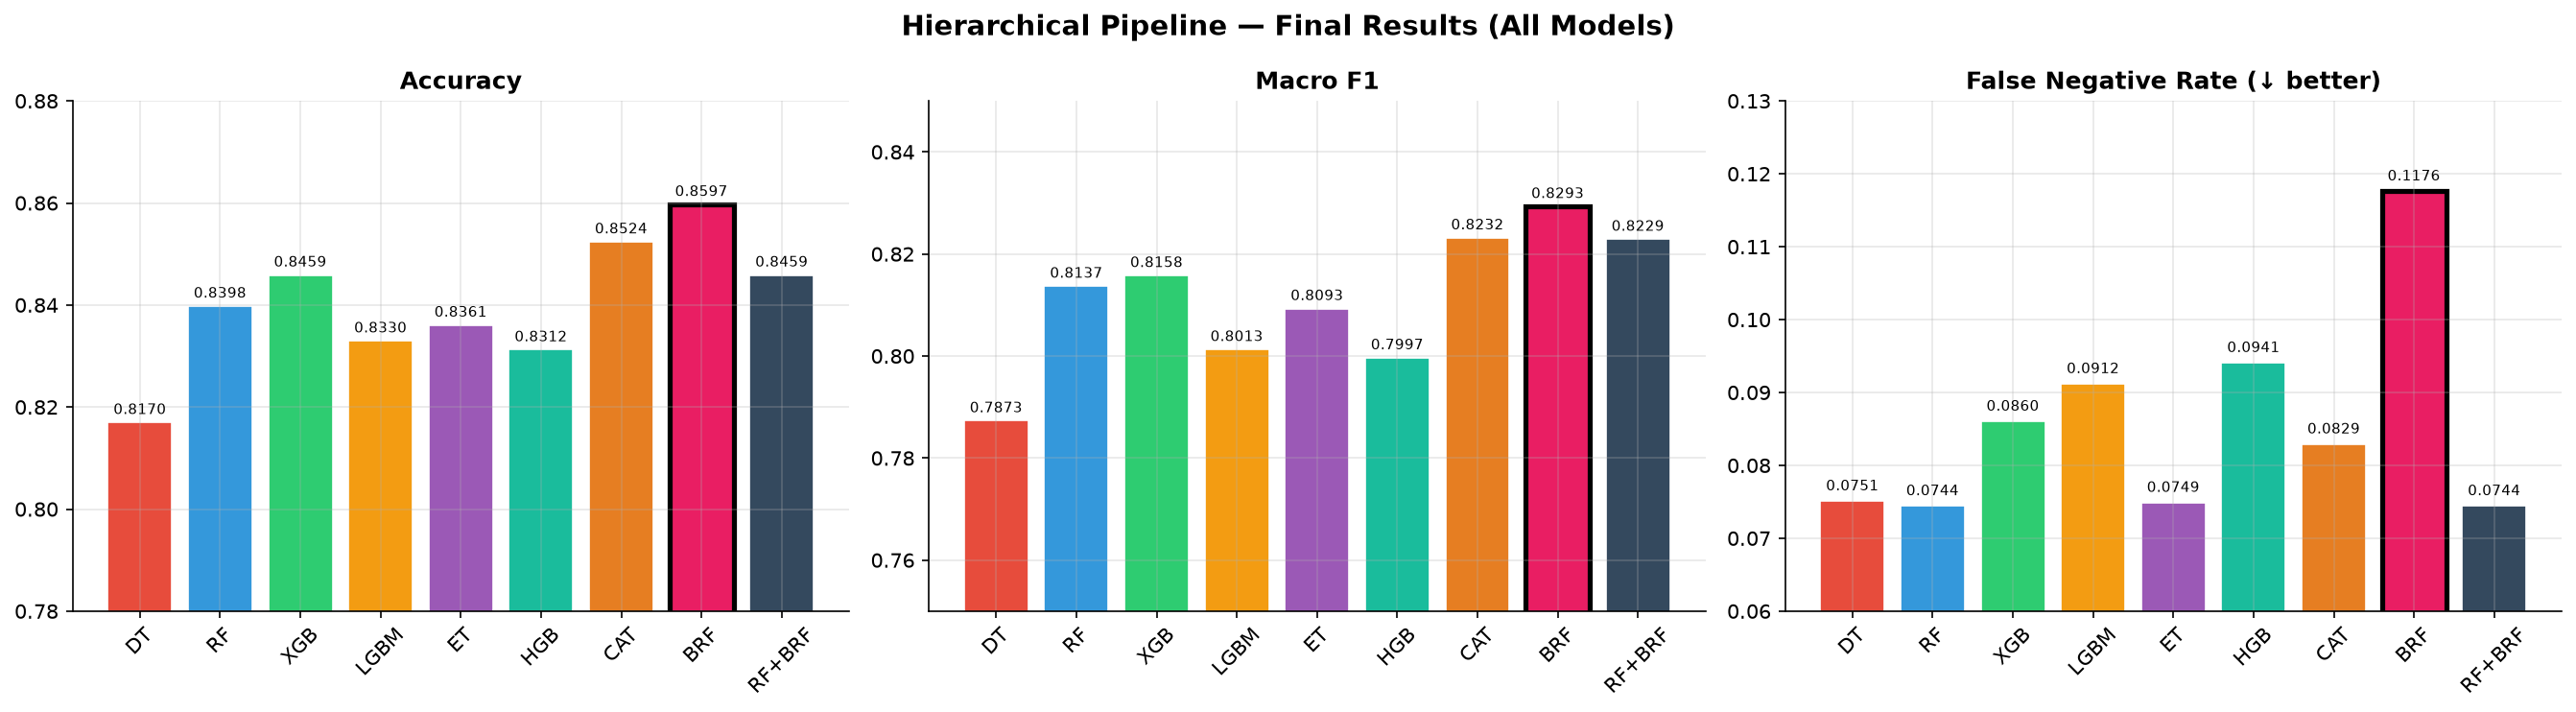

Saved: 01_final_comparison.png


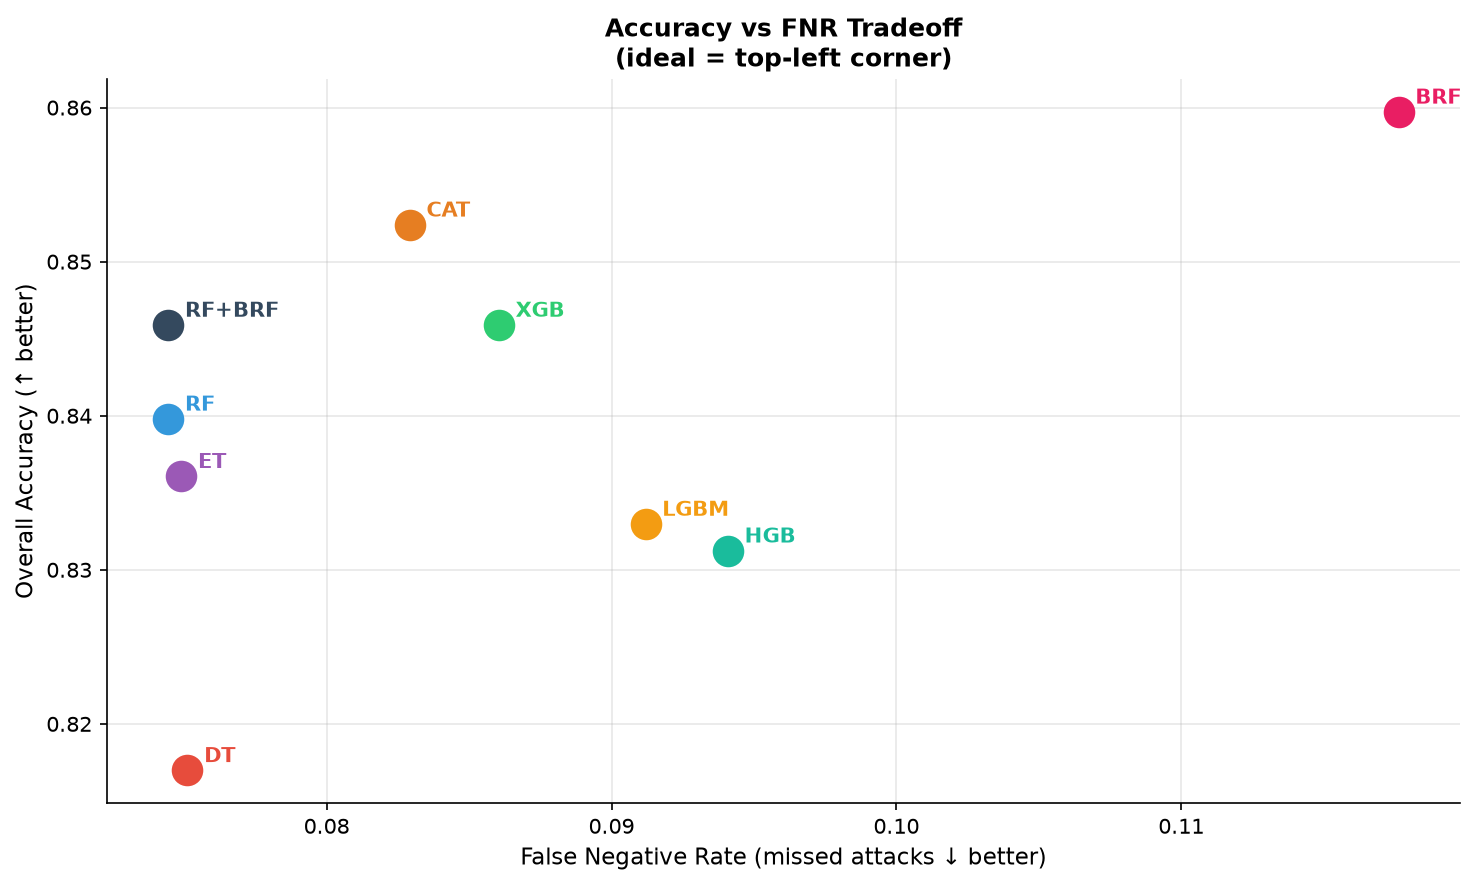

Saved: 02_accuracy_vs_fnr.png


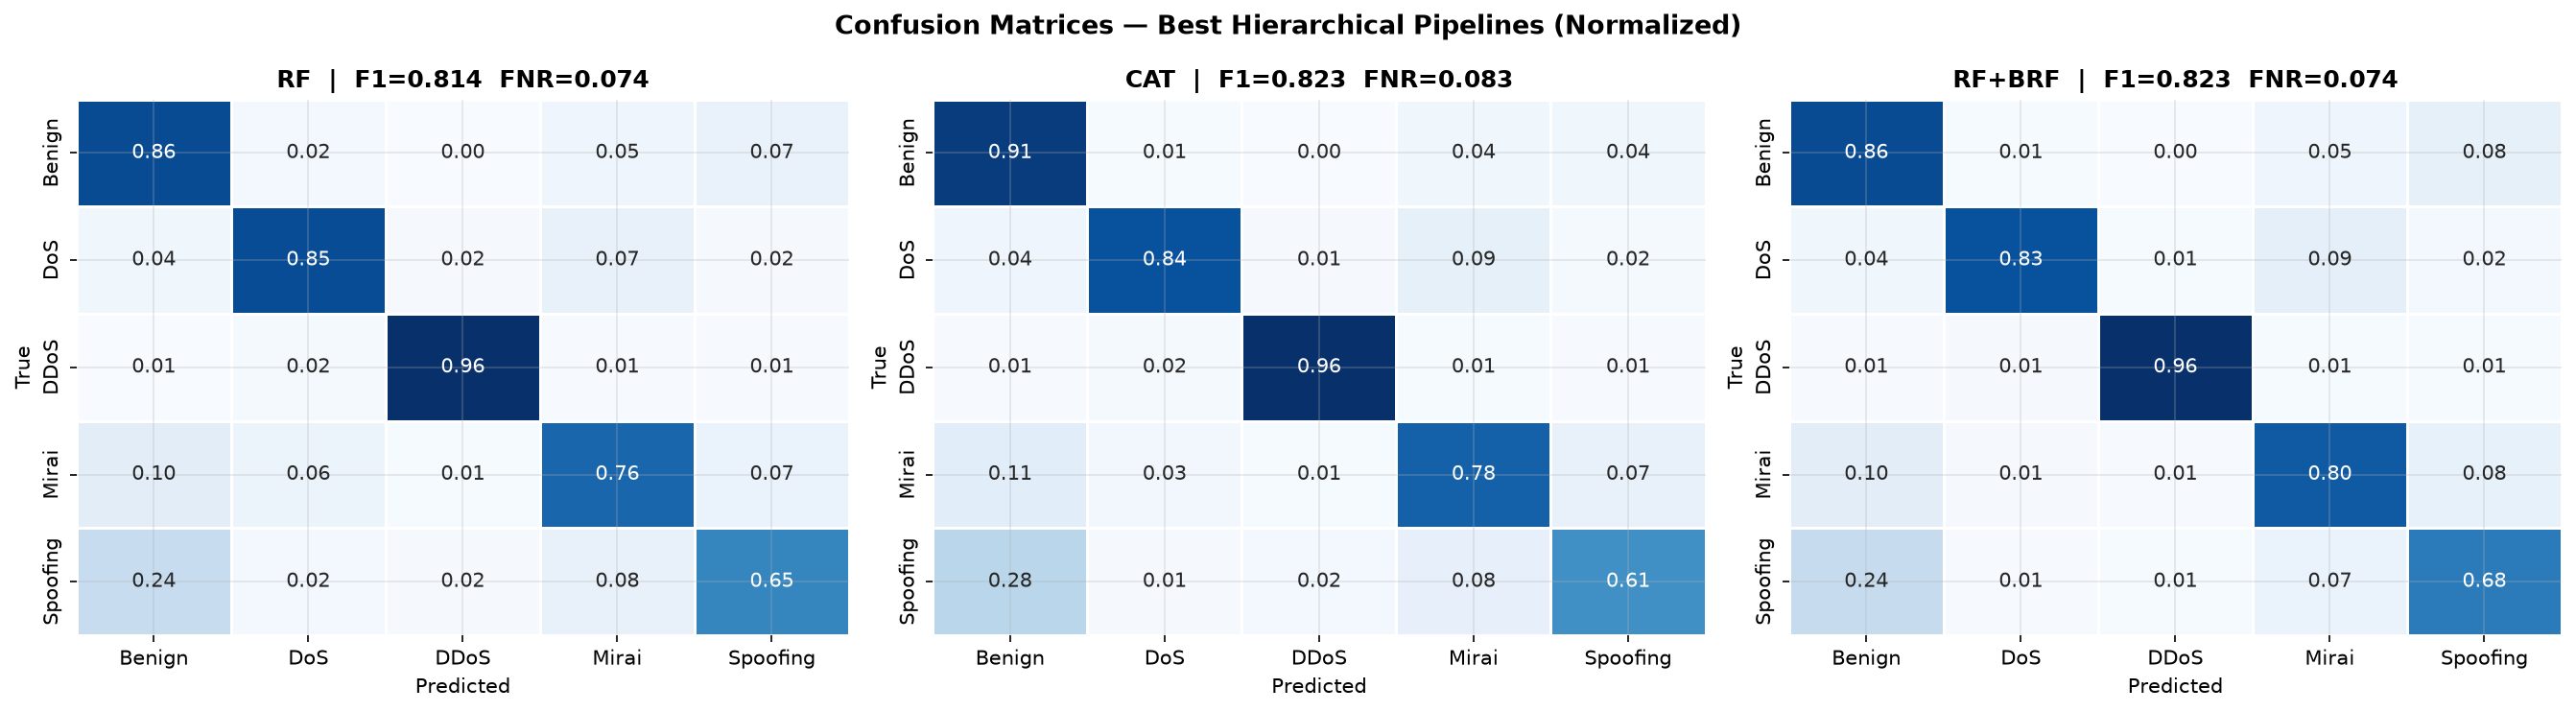

Saved: 03_confusion_matrices.png


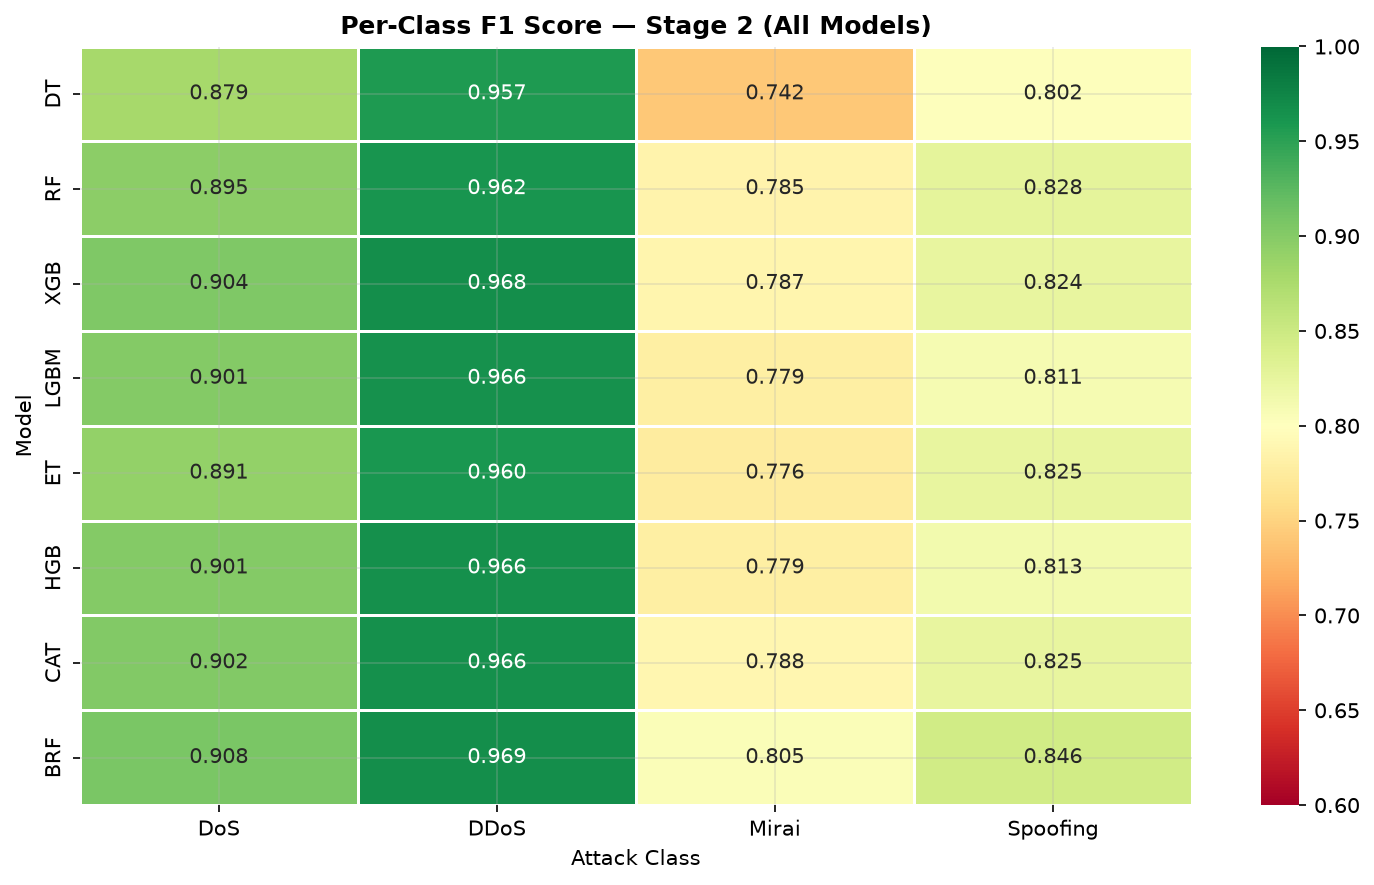

Saved: 04_perclass_f1_heatmap.png


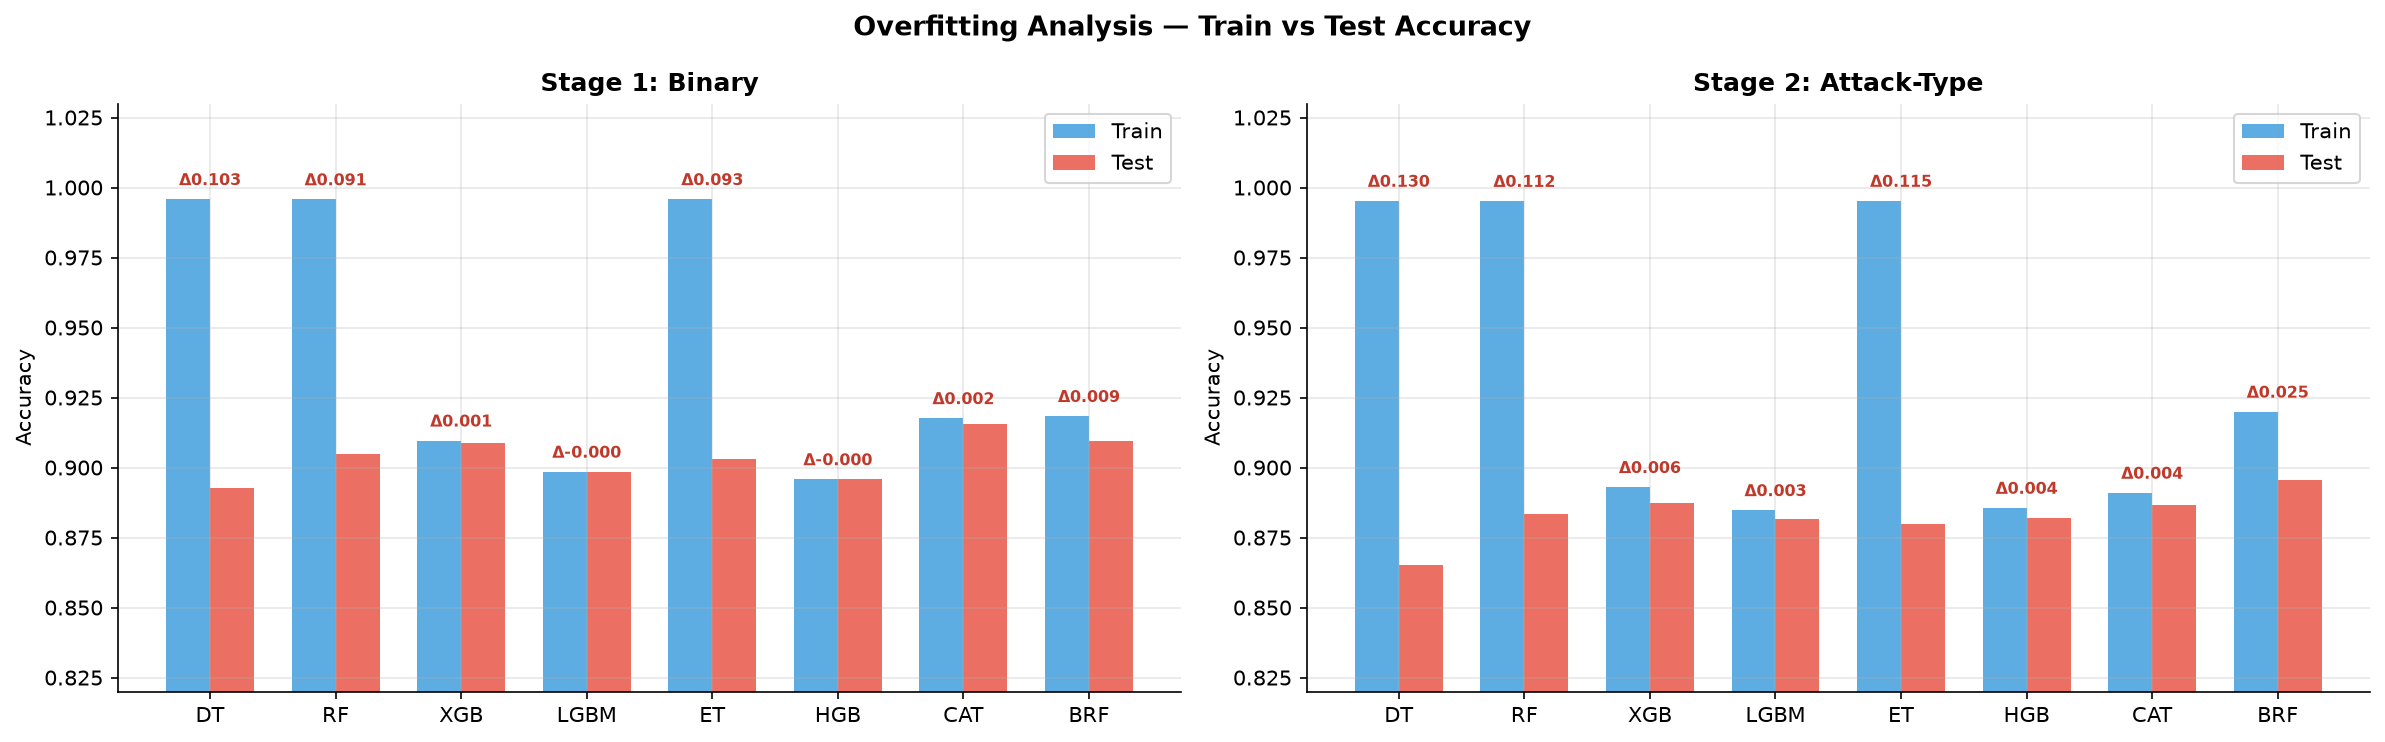

Saved: 05_overfitting.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

PALETTE = {
    'DT': '#e74c3c', 'RF': '#3498db', 'XGB': '#2ecc71',
    'LGBM': '#f39c12', 'ET': '#9b59b6', 'HGB': '#1abc9c',
    'CAT': '#e67e22', 'BRF': '#e91e63', 'RF+BRF': '#34495e'
}

all_names  = MODELS + ['RF+BRF']
all_acc    = [hierarchical_results[m]['accuracy'] for m in MODELS] + [acc_cross]
all_f1     = [hierarchical_results[m]['f1_macro'] for m in MODELS] + [f1_cross]
all_fnr    = [hierarchical_results[m]['false_negative_rate'] for m in MODELS] + [fnr_cross]
all_colors = [PALETTE[m] for m in all_names]

# ── Fig 1: Accuracy / F1 / FNR bar charts ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hierarchical Pipeline — Final Results (All Models)',
             fontsize=14, fontweight='bold')

for ax, vals, title, ylim in zip(
    axes,
    [all_acc, all_f1, all_fnr],
    ['Accuracy', 'Macro F1', 'False Negative Rate (↓ better)'],
    [(0.78, 0.88), (0.75, 0.85), (0.06, 0.13)]
):
    bars = ax.bar(all_names, vals, color=all_colors, edgecolor='white', linewidth=0.8)
    ax.set_ylim(ylim)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    best = np.argmin(vals) if 'FNR' in title else np.argmax(vals)
    bars[best].set_edgecolor('black')
    bars[best].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('../results/final/figures/01_final_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: 01_final_comparison.png")


# ── Fig 2: Accuracy vs FNR scatter ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for name, acc, fnr in zip(all_names, all_acc, all_fnr):
    ax.scatter(fnr, acc, color=PALETTE[name], s=200, zorder=5)
    ax.annotate(name, (fnr, acc), textcoords='offset points',
                xytext=(8, 4), fontsize=10, fontweight='bold', color=PALETTE[name])

ax.set_xlabel('False Negative Rate (missed attacks ↓ better)', fontsize=11)
ax.set_ylabel('Overall Accuracy (↑ better)', fontsize=11)
ax.set_title('Accuracy vs FNR Tradeoff\n(ideal = top-left corner)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/final/figures/02_accuracy_vs_fnr.png', bbox_inches='tight')
plt.show()
print("Saved: 02_accuracy_vs_fnr.png")


# ── Fig 3: Confusion matrices (best 3) ──────────────────────────────────────
best_models = [
    ('RF',     hierarchical_results['RF']['confusion_matrix']),
    ('CAT',    hierarchical_results['CAT']['confusion_matrix']),
    ('RF+BRF', cm_cross.tolist())
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Best Hierarchical Pipelines (Normalized)',
             fontsize=13, fontweight='bold')

for ax, (name, cm_list) in zip(axes, best_models):
    cm = np.array(cm_list)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    r = cross_result if name == 'RF+BRF' else hierarchical_results[name]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(f'{name}  |  F1={r["f1_macro"]:.3f}  FNR={r["false_negative_rate"]:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('../results/final/figures/03_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: 03_confusion_matrices.png")


# ── Fig 4: Per-class F1 heatmap (Stage 2) ───────────────────────────────────
attack_classes = ['DoS', 'DDoS', 'Mirai', 'Spoofing']
per_class_f1 = {}

for name in MODELS:
    y_pred = stage2_preds[name]
    labels = sorted(y_test_attack.unique())
    cm = confusion_matrix(y_test_attack, y_pred, labels=labels)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    prec = np.where((tp+fp)>0, tp/(tp+fp), 0)
    rec  = np.where((tp+fn)>0, tp/(tp+fn), 0)
    f1   = np.where((prec+rec)>0, 2*prec*rec/(prec+rec), 0)
    per_class_f1[name] = f1

f1_matrix = np.array([per_class_f1[m] for m in MODELS])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=attack_classes, yticklabels=MODELS,
            ax=ax, vmin=0.6, vmax=1.0, linewidths=0.5)
ax.set_title('Per-Class F1 Score — Stage 2 (All Models)', fontweight='bold')
ax.set_xlabel('Attack Class')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('../results/final/figures/04_perclass_f1_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: 04_perclass_f1_heatmap.png")


# ── Fig 5: Overfitting analysis ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Overfitting Analysis — Train vs Test Accuracy',
             fontsize=13, fontweight='bold')

for ax, (stage_data, title) in zip(axes, [
    (stage1_results, 'Stage 1: Binary'),
    (stage2_results, 'Stage 2: Attack-Type')
]):
    train_accs = [stage_data[m]['train_accuracy'] for m in MODELS]
    test_accs  = [stage_data[m]['accuracy'] for m in MODELS]
    x = np.arange(len(MODELS))
    w = 0.35
    ax.bar(x - w/2, train_accs, w, label='Train', color='#3498db', alpha=0.8)
    ax.bar(x + w/2, test_accs,  w, label='Test',  color='#e74c3c', alpha=0.8)
    for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
        ax.text(i, max(tr, te) + 0.005, f'Δ{tr-te:.3f}',
                ha='center', fontsize=7.5, color='#c0392b', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylim(0.82, 1.03)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/final/figures/05_overfitting.png', bbox_inches='tight')
plt.show()
print("Saved: 05_overfitting.png")

In [10]:
def make_json_safe(d):
    if isinstance(d, dict):  return {k: make_json_safe(v) for k, v in d.items()}
    if isinstance(d, list):  return [make_json_safe(v) for v in d]
    if isinstance(d, (np.integer,)):  return int(d)
    if isinstance(d, (np.floating,)): return float(d)
    return d

all_results = {
    'stage1_binary':         make_json_safe(stage1_results),
    'stage2_attack_type':    make_json_safe(stage2_results),
    'hierarchical_combined': make_json_safe(hierarchical_results),
    'cross_model_RF_BRF': make_json_safe({
        'accuracy':            acc_cross,
        'precision_macro':     prec_cross,
        'recall_macro':        rec_cross,
        'f1_macro':            f1_cross,
        'f1_weighted':         f1w_cross,
        'false_negative_rate': fnr_cross,
        'confusion_matrix':    cm_cross.tolist(),
        'labels':              CLASS_NAMES
    })
}

with open('../results/final/hierarchical_final_results.json', 'w') as f:
    json.dump(make_json_safe(all_results), f, indent=2)

print("✓ Results saved to ../results/final/hierarchical_final_results.json")
print("✓ Models saved to ../results/models/")
print("✓ Figures saved to ../results/final/figures/")

✓ Results saved to ../results/final/hierarchical_final_results.json
✓ Models saved to ../results/models/
✓ Figures saved to ../results/final/figures/
